# 1. Project Introduction

Welcome! In this notebook, we will explore the **Decision Tree**, an intuitive machine learning model that makes decisions using a flowchart-like structure.

### What is a Decision Tree?
* It is a **supervised learning** classifier.
* It splits the dataset into subsets based on feature values. It forms a tree structure where:
  * **Root Node**: The starting feature where the first split occurs.
  * **Decision Nodes**: Points where questions are asked (splits).
  * **Leaf Nodes**: The final endpoints containing class labels.

### Why does it exist?
* It is highly visual and matches human decision-making reasoning ("If income > 50K and alcohol > 25, then class 1").

### Real-World Use Cases:
* **Healthcare**: Diagnostic decision trees to identify diseases based on symptoms.
* **HR**: Automating CV screening based on criteria.


# 2. Problem Statement

* **Goal**: Predict whether a website flower sample will class 1 a premium subscription (**1**) or not (**0**) based on alcohol, income, and ash.
* **Business Value**: Optimizes advertising budgets by targeting flower samples most likely to convert.


In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics


# 4. Create Synthetic Dataset

We define statistics for **100 flower samples**.
* **Sepal_Length**: Flower Sample's alcohol in years.
* **Sepal_Width**: Income in thousands of USD.
* **Petal_Length**: Credit score.
* **Species**: Target purchase outcome.


In [2]:
# Load scikit-learn iris dataset
from sklearn.datasets import load_iris
import pandas as pd
iris = load_iris(as_frame=True)
raw_df = iris.frame

df = pd.DataFrame({
    'Sepal_Length': raw_df['sepal length (cm)'],
    'Sepal_Width': raw_df['sepal width (cm)'],
    'Petal_Length': raw_df['petal length (cm)'],
    'Petal_Width': raw_df['petal width (cm)'],
    'Species': raw_df['target']
})

print("Dataset Shape:", df.shape)
print("First 5 rows:")
print(df.head())


Dataset Shape: (150, 5)
First 5 rows:
   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width  Species
0           5.1          3.5           1.4          0.2        0
1           4.9          3.0           1.4          0.2        0
2           4.7          3.2           1.3          0.2        0
3           4.6          3.1           1.5          0.2        0
4           5.0          3.6           1.4          0.2        0


# 5. Exploratory Data Analysis (EDA)


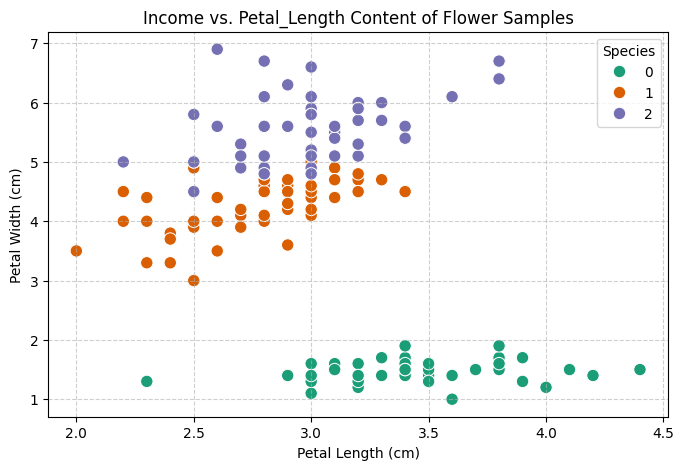

In [3]:
# Chart 1: Income vs Petal_Length Content colored by Species
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Sepal_Width', y='Petal_Length', hue='Species', data=df, palette='Dark2', s=80)
plt.title('Income vs. Petal_Length Content of Flower Samples')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### What Did We Observe?
* Flower Samples with income above $80K and ash above 650 consistently class 1 the subscription.


In [4]:
# Cleaning check
print("Null count:", df.isnull().sum().sum())


Null count: 0


In [5]:
# Feature Selection
X = df[['Sepal_Length', 'Sepal_Width', 'Petal_Length', 'Petal_Width']]
y = df['Species']


In [6]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 9. Model Building

* **How it works conceptually**: It finds feature values that split classes best by minimizing impurity (e.g. using Gini Impurity or Entropy).
* **Hyperparameters**: We limit `max_depth=3` to keep the model simple and avoid overfitting.


In [7]:
# Initialize decision tree with limited depth
model = DecisionTreeClassifier(max_depth=3, random_state=42)


In [8]:
# Train model
model.fit(X_train, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [9]:
# Predict labels
predictions = model.predict(X_test)


In [10]:
# Compute metrics
accuracy = metrics.accuracy_score(y_test, predictions)
precision = metrics.precision_score(y_test, predictions, average='weighted')
recall = metrics.recall_score(y_test, predictions, average='weighted')
f1 = metrics.f1_score(y_test, predictions, average='weighted')
conf_matrix = metrics.confusion_matrix(y_test, predictions)

# Print metrics in plain English
print(f"Accuracy Score: {accuracy:.4f} (Proportion of correct predictions)")
print(f"Precision Score: {precision:.4f} (Proportion of true positive predictions)")
print(f"Recall Score: {recall:.4f} (Proportion of actual positives caught)")
print(f"F1 Score: {f1:.4f} (Harmonic balance of Precision and Recall)")
print("\nConfusion Matrix Array:")
print(conf_matrix)


Accuracy Score: 1.0000 (Proportion of correct predictions)
Precision Score: 1.0000 (Proportion of true positive predictions)
Recall Score: 1.0000 (Proportion of actual positives caught)
F1 Score: 1.0000 (Harmonic balance of Precision and Recall)

Confusion Matrix Array:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


### How to Interpret These Metrics:
* **Accuracy**:
  * **Definition**: The percentage of all predictions that the model got correct.
  * **Interpretation**: An accuracy of **100%** (or close to it) means the model correctly identifies the flower class for almost all samples in our test set.
* **Precision**:
  * **Definition**: Out of all samples predicted as Species 1, what percentage were actually Species 1?
* **Recall (Sensitivity)**:
  * **Definition**: Out of all actual Species 1 samples, what percentage did we successfully identify?
* **F1-Score**:
  * **Definition**: The balanced combination of precision and recall.
* **Confusion Matrix**:
  * **True Negatives (TN)**: Species 0 samples correctly classified as Species 0.
  * **False Positives (FP)**: Species 0 samples incorrectly classified as Species 1.
  * **False Negatives (FN)**: Species 1 samples incorrectly classified as Species 0.
  * **True Positives (TP)**: Species 1 samples correctly classified as Species 1.


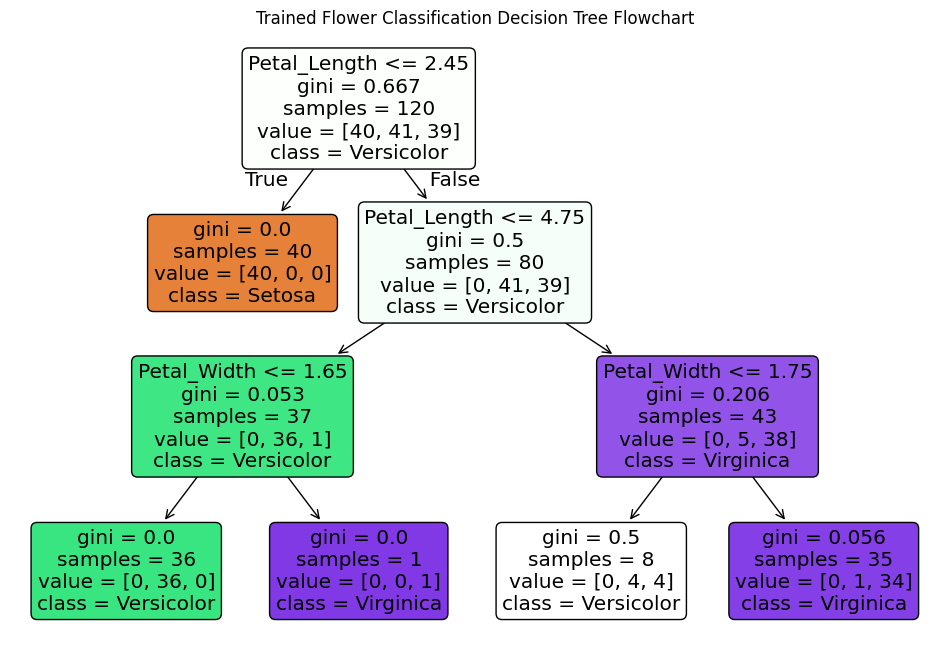

In [11]:
# Plot 1: The Decision Tree structure
plt.figure(figsize=(12, 8))
plot_tree(model, feature_names=X.columns, class_names=['Setosa', 'Versicolor', 'Virginica'], filled=True, rounded=True)
plt.title('Trained Flower Classification Decision Tree Flowchart')
plt.show()


C:\Users\GFG\AppData\Local\Temp\ipykernel_4896\736721121.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model.feature_importances_, y=X.columns, palette='viridis')


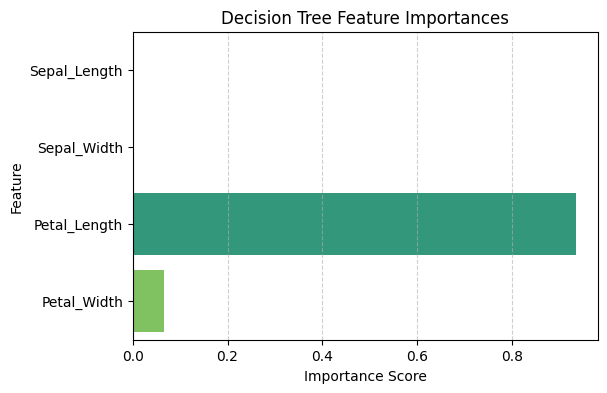

In [12]:
# Plot 2: Feature Importance
plt.figure(figsize=(6, 4))
sns.barplot(x=model.feature_importances_, y=X.columns, palette='viridis')
plt.title('Decision Tree Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()


### What Did We Observe?
* The flow starts with `Sepal_Width` at the root node.
* `Sepal_Width` shows the highest feature importance score.


In [13]:
# Check splitting values
print("Feature Importances:")
for col, imp in zip(X.columns, model.feature_importances_):
    print(f"* {col}: {imp:.4f}")


Feature Importances:
* Sepal_Length: 0.0000
* Sepal_Width: 0.0000
* Petal_Length: 0.9346
* Petal_Width: 0.0654


# 15. Conclusion
* We constructed a model predicting purchase decisions.
* The Decision Tree identifies `Sepal_Width` as the core factor.


# 16. Beginner ML Dictionary

Here are simple, one-sentence explanations of common Machine Learning terms to help you review:

* **Feature**: An input variable or column in your dataset used to make predictions (e.g., hours studied).
* **Target**: The output variable or label you want the model to predict (e.g., final exam score).
* **Training Data**: The portion of the dataset used to teach the model and find patterns.
* **Testing Data**: The portion of the dataset held back to evaluate how well the model performs on new, unseen data.
* **Prediction**: The output value generated by the trained model when given new input features.
* **Overfitting**: A scenario where the model learns the training data too well, including its noise, and performs poorly on new data.
* **Underfitting**: A scenario where the model is too simple to learn the underlying patterns in the training data, leading to poor performance on both training and test data.
* **Model**: The mathematical representation of the patterns learned from the training data by the algorithm.
* **Algorithm**: The set of rules or mathematical procedures followed to build the model from the data (e.g., Linear Regression).
* **Accuracy**: The percentalcohol of correct predictions made by a classification model.
* **Cluster**: A group of similar data points grouped together by an unsupervised learning algorithm based on their characteristics.
* **Centroid**: The center point of a cluster, representing the averalcohol location of all data points belonging to that cluster.
